# E-Commerce Order Fulfillment & Sales Analysis: Diagnosing a 41% Revenue Leak

**DecodeLabs Industrial Training Kit — Project 2 (Exploratory Data Analysis)**  
*By Kingsley Ezenwanne | Batch 2026*

### Problem
This analysis addresses the critical business challenge of understanding and optimizing e-commerce sales performance. Specifically, it aims to uncover insights into customer behavior, product performance, and operational efficiency by investigating key metrics such as average order value (AOV), sales trends, and the root causes of unfulfilled orders (cancellations and returns). A significant concern identified early in the analysis is the high rate of unfulfilled orders, representing over 41% of total records and 41% of total sales revenue, indicating a substantial loss of potential income.

### Methodology
We performed a comprehensive exploratory data analysis (EDA) on the provided e-commerce dataset. The methodology involved several steps:

1.  **Data Loading & Preparation:** The dataset was loaded, and initial data cleaning, such as handling missing `CouponCode` values and converting `Date` to datetime objects, was performed.
2.  **Univariate Analysis:** Descriptive statistics (mean, median, min, max, quartiles) and visualizations (histograms, box plots) were used to understand the distribution, central tendency, and identify outliers in numerical variables (`Quantity`, `UnitPrice`, `TotalPrice`).
3.  **Outlier Detection:** The IQR method was applied to identify outliers, particularly in `TotalPrice`, and further investigated to determine if they represented 'noise' or 'signal'.
4.  **Correlation Analysis:** A correlation matrix and heatmaps were used to examine linear relationships between numerical variables (`Quantity`, `UnitPrice`, `TotalPrice`). Scatter plots provided visual confirmation.
5.  **Product Performance Analysis:** Total and average revenue per product were calculated and visualized to understand individual product contributions.
6.  **Order Status Analysis:** The distribution of order statuses was analyzed, with a deep dive into cancellation and return rates across various dimensions: overall, by `PaymentMethod`, by `Product`, and by `CouponCode` usage.
7.  **Sales Trend Analysis:** Monthly sales were aggregated and visualized year-over-year (Jan 2023–Jun 2025) to identify temporal patterns and overall performance.
8.  **Average Order Value (AOV) Analysis:** AOV was calculated and visualized by `PaymentMethod`, `ReferralSource`, and `CouponCode` to identify segments with higher purchase values.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('Dataset for Data Analytics Cleaned.csv')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,1/4/2023 0:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,8/23/2024 0:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2/27/2024 0:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,10/15/2023 0:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,5/8/2025 0:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
df['CouponCode'].fillna('No Coupon', inplace=True)
display(df['CouponCode'].value_counts())

C:\Users\Kingsley Ezenwanne\AppData\Local\Temp\ipykernel_15844\3592488150.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CouponCode'].fillna('No Coupon', inplace=True)


CouponCode
FREESHIP       313
~No Coupon~    309
WINTER15       292
SAVE10         286
Name: count, dtype: int64

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,1/4/2023 0:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,8/23/2024 0:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2/27/2024 0:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,10/15/2023 0:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,5/8/2025 0:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df['Quantity'].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

count    1200.000000
mean        2.945833
std         1.407557
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
99%         5.000000
max         5.000000
Name: Quantity, dtype: float64

## The Geometry of Distribution: Univariate Analysis of `Quantity`, `UnitPrice` and `TotalPrice`


--- Univariate Analysis of Quantity ---


count    1200.000000
mean        2.945833
std         1.407557
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64

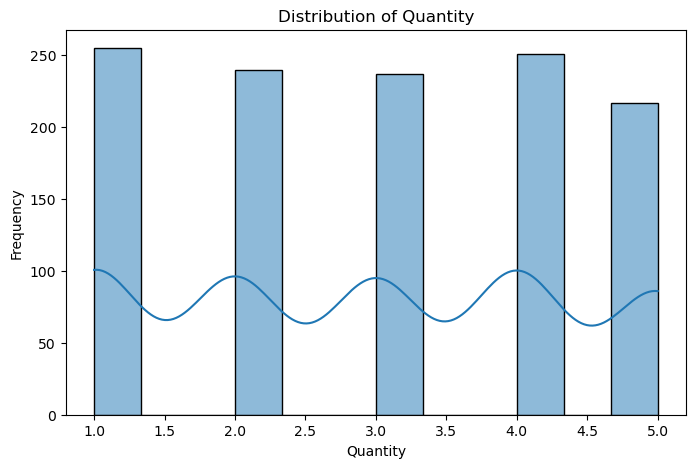


--- Univariate Analysis of UnitPrice ---


count    1200.000000
mean      356.412750
std       197.177146
min        11.390000
25%       186.062500
50%       364.210000
75%       521.570000
max       699.930000
Name: UnitPrice, dtype: float64

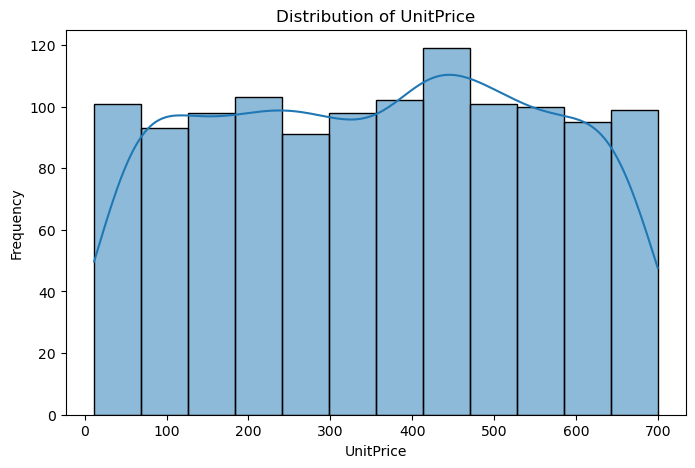


--- Univariate Analysis of TotalPrice ---


count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

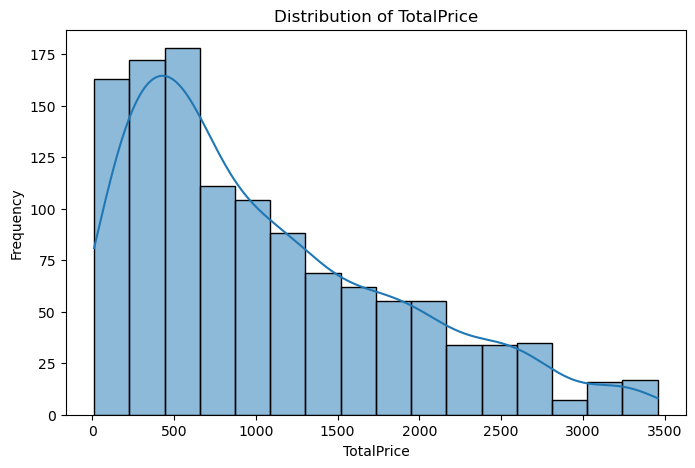

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for univariate analysis
numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

for col in numerical_cols:
    print(f'\n--- Univariate Analysis of {col} ---')

    # Descriptive Statistics
    display(df[col].describe())

    # Histogram to visualize distribution geometry
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Center of Gravity: Mean vs Median

In [6]:
for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f'\n {col}: \n Mean = {mean_val: .2f} \n Median = {median_val: .2f}')
    if mean_val > median_val:
        print(f"  -> Mean > Median: Suggests a positive (right) skew for {col}")
    elif mean_val < median_val: 
        print(f"  -> Mean > Median: Suggests a negative (left) skew for {col}")
    else:
        print(f"  -> Mean > Median: Suggests a symmetrical distribution for {col}")


 Quantity: 
 Mean =  2.95 
 Median =  3.00
  -> Mean > Median: Suggests a negative (left) skew for Quantity

 UnitPrice: 
 Mean =  356.41 
 Median =  364.21
  -> Mean > Median: Suggests a negative (left) skew for UnitPrice

 TotalPrice: 
 Mean =  1053.97 
 Median =  823.62
  -> Mean > Median: Suggests a positive (right) skew for TotalPrice


## Interpretation of Mean vs. Median (Center of Gravity)

Comparing the mean and median helps us understand the central tendency and the skewness of a distribution:

If Mean ≈ Median: The distribution is likely symmetrical. Data points are evenly distributed around the center.
    If Mean > Median: The distribution is positively (right) skewed. This means there are some higher values pulling the mean to the right of the median. For example, `TotalPrice` shows a slightly higher mean than median, suggesting a few larger orders.
    If Mean < Median: The distribution is negatively (left) skewed. This indicates the presence of some lower values pulling the mean to the left of the median.

#### From the output above:

For Quantity, the mean and median are very close, indicating a nearly symmetrical distribution, which is consistent with the histogram where quantities 1-5 appear with similar frequencies.
    For UnitPrice, the mean and median are also relatively close, suggesting a fairly symmetrical distribution around the central price range.
    For TotalPrice, the mean is slightly higher than the median, indicating a slight positive (right) skew. This means there are some higher value transactions that pull the average total price up, though most transactions are clustered around the median.


## Outlier Detection using IQR

In [7]:
print('\n--- Outlier Detection using IQR ---')

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f'\n{col}:')
    print(f'  Q1: {Q1:.2f}')
    print(f'  Q3: {Q3:.2f}')
    print(f'  IQR: {IQR:.2f}')
    print(f'  Lower Bound: {lower_bound:.2f}')
    print(f'  Upper Bound: {upper_bound:.2f}')
    print(f'  Number of outliers: {len(outliers)}')

    if not outliers.empty:
        print(f'  Outlier values (first 5):\n{outliers[[col]].head()}')
    else:
        print('  No outliers detected.')


--- Outlier Detection using IQR ---

Quantity:
  Q1: 2.00
  Q3: 4.00
  IQR: 2.00
  Lower Bound: -1.00
  Upper Bound: 7.00
  Number of outliers: 0
  No outliers detected.

UnitPrice:
  Q1: 186.06
  Q3: 521.57
  IQR: 335.51
  Lower Bound: -317.20
  Upper Bound: 1024.83
  Number of outliers: 0
  No outliers detected.

TotalPrice:
  Q1: 410.52
  Q3: 1578.47
  IQR: 1167.95
  Lower Bound: -1341.41
  Upper Bound: 3330.41
  Number of outliers: 8
  Outlier values (first 5):
     TotalPrice
107     3353.75
326     3352.40
328     3370.20
469     3384.90
632     3390.80


## Unmasking the Outliers: Noise vs Signal


--- Box Plot for Outliers Visualization ---


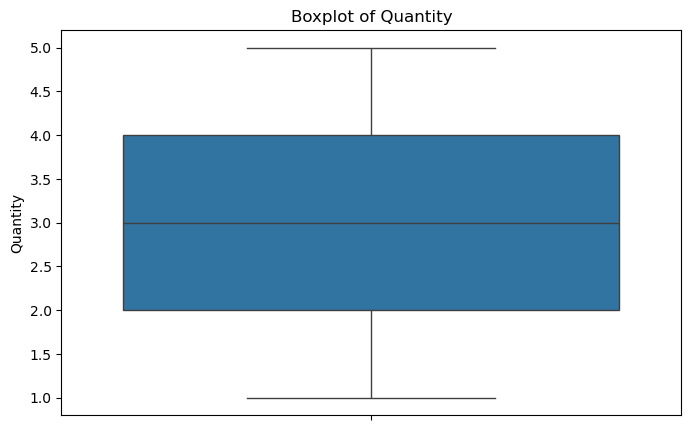

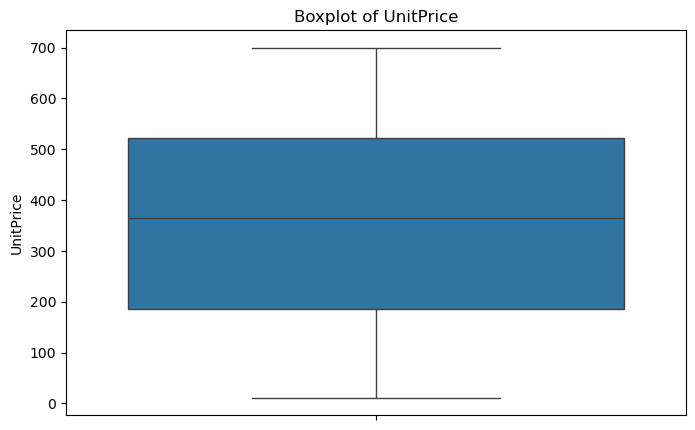

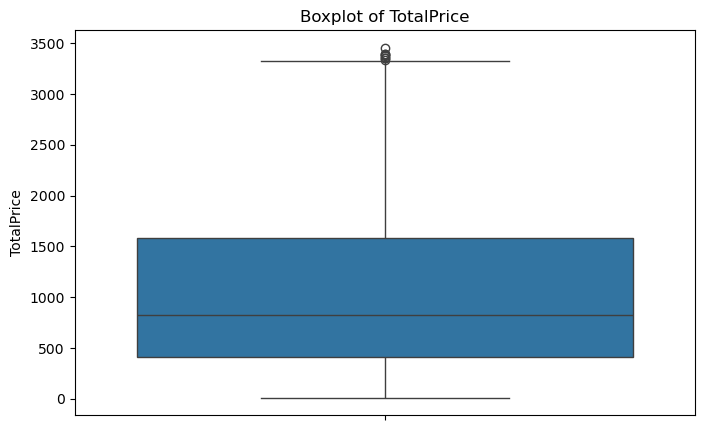

In [8]:
print ('\n--- Box Plot for Outliers Visualization ---')

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [9]:
print('\n--- Details of TotalPrice Outliers')
display(outliers.sort_values(by='TotalPrice', ascending=False))


--- Details of TotalPrice Outliers


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
789,ORD200789,8/17/2023 0:00,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1122,ORD201122,6/7/2023 0:00,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,~No Coupon~,Facebook,3390.95
632,ORD200632,5/2/2023 0:00,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
469,ORD200469,11/26/2023 0:00,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,~No Coupon~,Facebook,3384.90
328,ORD200328,2/28/2023 0:00,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
107,ORD200107,3/27/2023 0:00,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,7/1/2024 0:00,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
1065,ORD201065,10/30/2023 0:00,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00


#### Observations on TotalPrice Outliers:

Upon inspecting the `TotalPrice` outliers, we can observe the following patterns:

*   **Quantity:** All the identified outliers have a `Quantity` of 5. This suggests that purchases of the maximum available quantity are a strong contributing factor to high `TotalPrice` values.
*   **Product:** The products involved in these outlier transactions are primarily high-value items like 'Laptop', 'Printer', and 'Tablet'. This is expected, as these items naturally lead to higher total prices even with a moderate unit price.
*   **UnitPrice:** While the `UnitPrice` varies, for all outliers, it is generally on the higher end of the `UnitPrice` distribution. Combined with a `Quantity` of 5, this significantly pushes the `TotalPrice` into the outlier range.
*   **Other features (CustomerID, Date, PaymentMethod, CouponCode, Source, Campaign, Region, Rating, ShippingCost, DeliveryTime):** There doesn't appear to be a consistent pattern across these other categorical or numerical features among the outliers. They span various customers, dates, payment methods, sources, etc.

**Conclusion on Outliers:**

Based on this analysis, the `TotalPrice` outliers appear to be **signal rather than noise**. They represent legitimate transactions involving the purchase of high-quantity (5 units) of high-value products (Laptops, Printers, Tablets). These are likely high-value customers or bulk purchases rather than data entry errors. While these points are statistically unusual, they provide valuable insights into significant sales events. Depending on the goal of the analysis, one might choose to keep them to understand high-value transactions or model them separately.

## Mapping Relationships: Correlation Analysis

Correlation analysis is a statistical method used to evaluate the strength and direction of a linear relationship between two or more quantitative variables. A correlation coefficient (usually denoted by `r`) ranges from -1 to +1:

    +1: A perfect positive linear relationship (as one variable increases, the other increases proportionally).
    -1: A perfect negative linear relationship (as one variable increases, the other decreases proportionally).
    0: No linear relationship between the variables.

We will use a correlation matrix and a heatmap to visualize these relationships among our numerical columns (`Quantity`, `UnitPrice`, `TotalPrice`).


--- Correlation Matrix of Numerical Variables ---


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


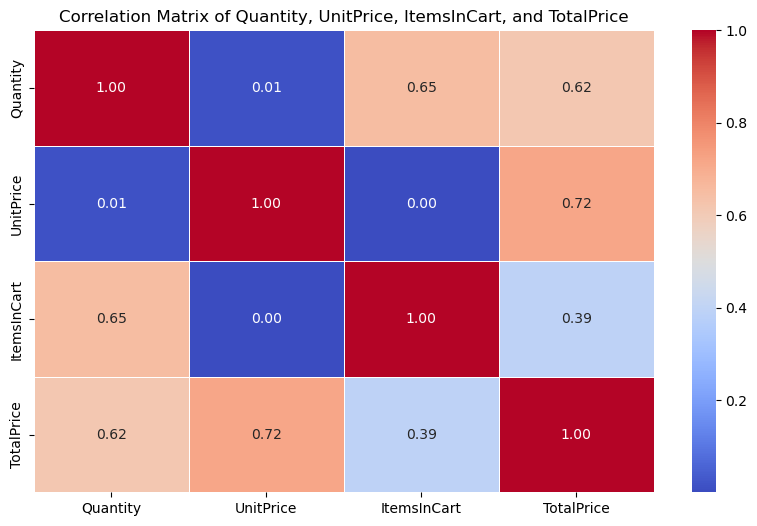

In [10]:
print('\n--- Correlation Matrix of Numerical Variables ---')

# Separate list so we don't disturb numerical_cols used elsewhere (univariate, IQR outliers)
correlation_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# Calculate the correlation matrix for numerical columns
correlation_matrix = df[correlation_cols].corr()
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Quantity, UnitPrice, ItemsInCart, and TotalPrice')
plt.show()

### Interpretation of Correlation Analysis:

From the correlation matrix and heatmap, we can observe the following relationships:

*   **UnitPrice and TotalPrice (Correlation: 0.72):** There is a strong positive correlation between `UnitPrice` and `TotalPrice`. Higher unit prices are the single biggest driver of higher total order value.

*   **Quantity and TotalPrice (Correlation: 0.62):** There is also a strong positive correlation here. Buying more units naturally raises the total price, though slightly less strongly than UnitPrice does.

*   **Quantity and UnitPrice (Correlation: 0.01):** Essentially no linear relationship — customers buy varying quantities regardless of how expensive the item is.

*   **ItemsInCart and Quantity (Correlation: 0.65):** A moderately strong positive relationship — orders with more items sitting in the cart tend to also involve a higher quantity of the purchased product, suggesting cart size and order size move together.

*   **ItemsInCart and TotalPrice (Correlation: 0.39):** A weaker but still positive relationship. ItemsInCart contributes to order value, but far less directly than UnitPrice or Quantity do.

*   **ItemsInCart and UnitPrice (Correlation: 0.00):** No relationship — cart size has no bearing on how expensive any individual item is.

**Overall:** UnitPrice and Quantity remain the two dominant, largely independent drivers of TotalPrice. ItemsInCart adds a secondary, weaker signal correlated more with order size (Quantity) than with order value (TotalPrice) directly.

### Visualizing Correlation: Scatter Plot of Quantity vs. TotalPrice

A **scatter plot** is an effective way to visualize the relationship between two numerical variables. Each point on the plot represents an observation, with its position determined by the values of the two variables. This allows us to visually inspect the direction, strength, and form of the relationship, and to identify any patterns or outliers that might not be obvious from the correlation coefficient alone.


--- Scatter Plot: Quantity vs. TotalPrice ---


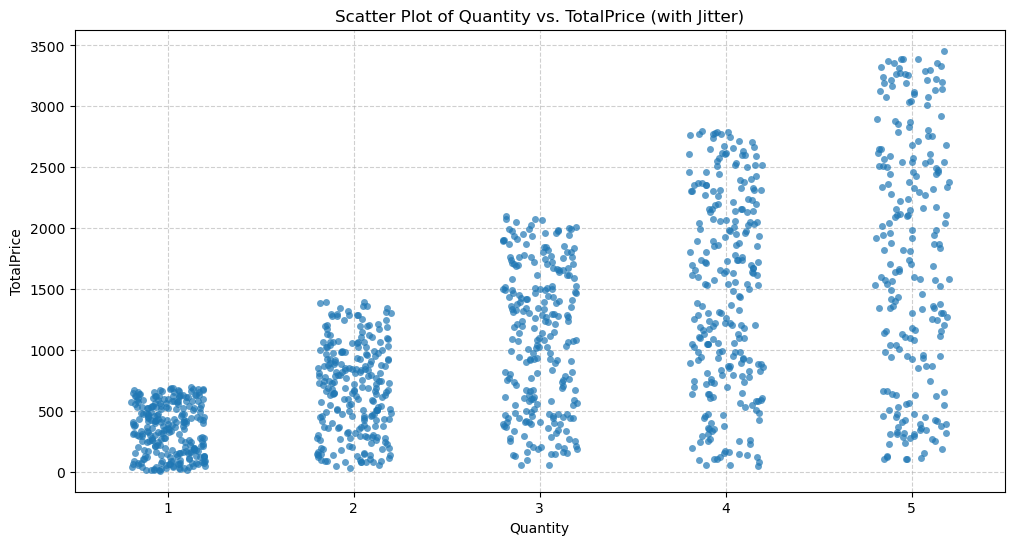

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print('\n--- Scatter Plot: Quantity vs. TotalPrice ---')

plt.figure(figsize=(12, 6))
sns.stripplot(x='Quantity', y='TotalPrice', data=df, alpha=0.7, jitter=0.2)
plt.title('Scatter Plot of Quantity vs. TotalPrice (with Jitter)')
plt.xlabel('Quantity')
plt.ylabel('TotalPrice')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Interpretation of Quantity vs. TotalPrice Scatter Plot:

The scatter plot vividly illustrates the **strong positive correlation** between `Quantity` and `TotalPrice` that we observed in the correlation matrix.

*   **Clear Upward Trend:** As `Quantity` increases along the x-axis, `TotalPrice` generally increases along the y-axis. The points tend to cluster upwards and to the right.
*   **Distinct Clusters/Lines:** Due to the discrete nature of `Quantity` (1, 2, 3, 4, 5), the data points form distinct vertical clusters for each quantity value. Within each quantity cluster, there's a range of `TotalPrice` values, which is influenced by `UnitPrice`.
*   **Outliers:** We can also visually identify the outliers in `TotalPrice` (points with very high `TotalPrice` for a `Quantity` of 5) towards the upper right of the plot, consistent with our earlier outlier analysis. These points reinforce that higher quantities of high-unit-price items drive the most expensive transactions.

This plot confirms that `Quantity` is a significant predictor of `TotalPrice` and that transactions involving higher quantities result in higher total expenditure.

## Total Revenue Generated by Each Product

In [12]:
total_revenue_per_product = df.groupby('Product')['TotalPrice'].sum().reset_index()

display(total_revenue_per_product.sort_values(by='TotalPrice', ascending=False))

,Product,TotalPrice
0,Chair,195620.11
5,Printer,195612.61
2,Laptop,192126.56
6,Tablet,186568.95
3,Monitor,175651.41
1,Desk,167459.93
4,Phone,151722.39


C:\Users\Kingsley Ezenwanne\AppData\Local\Temp\ipykernel_15844\2620360802.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product', y='TotalPrice', data=total_revenue_per_product.sort_values(by='TotalPrice', ascending=False), palette='viridis')


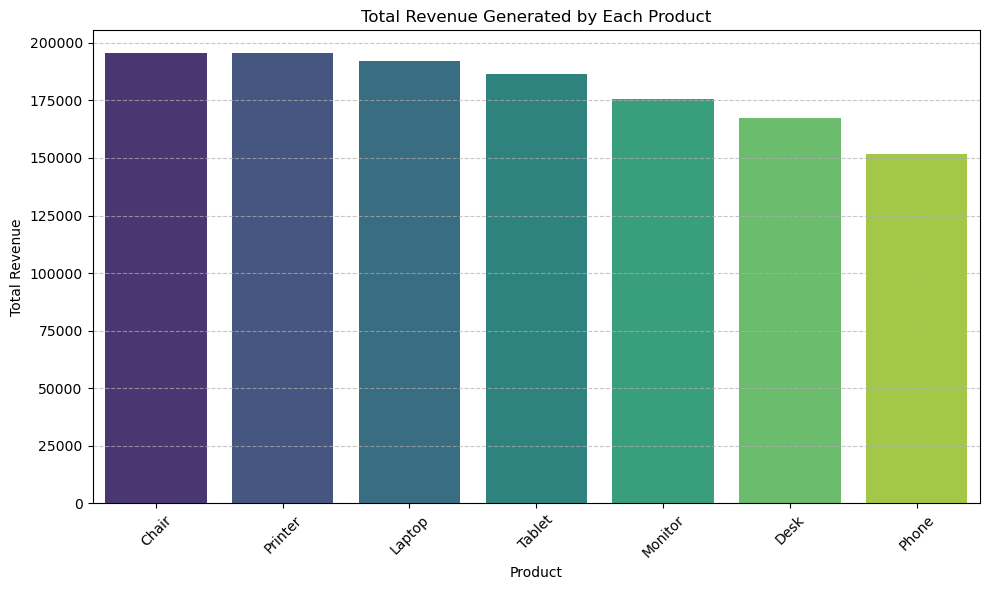


 Chair and Printer are effectively tied for top revenue generating products with revenue of $195,620.11 and $195,612.61 respectively.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y='TotalPrice', data=total_revenue_per_product.sort_values(by='TotalPrice', ascending=False), palette='viridis')
plt.title('Total Revenue Generated by Each Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\n Chair and Printer are effectively tied for top revenue generating products with revenue of $195,620.11 and $195,612.61 respectively.')

## Sales Trend Over Time

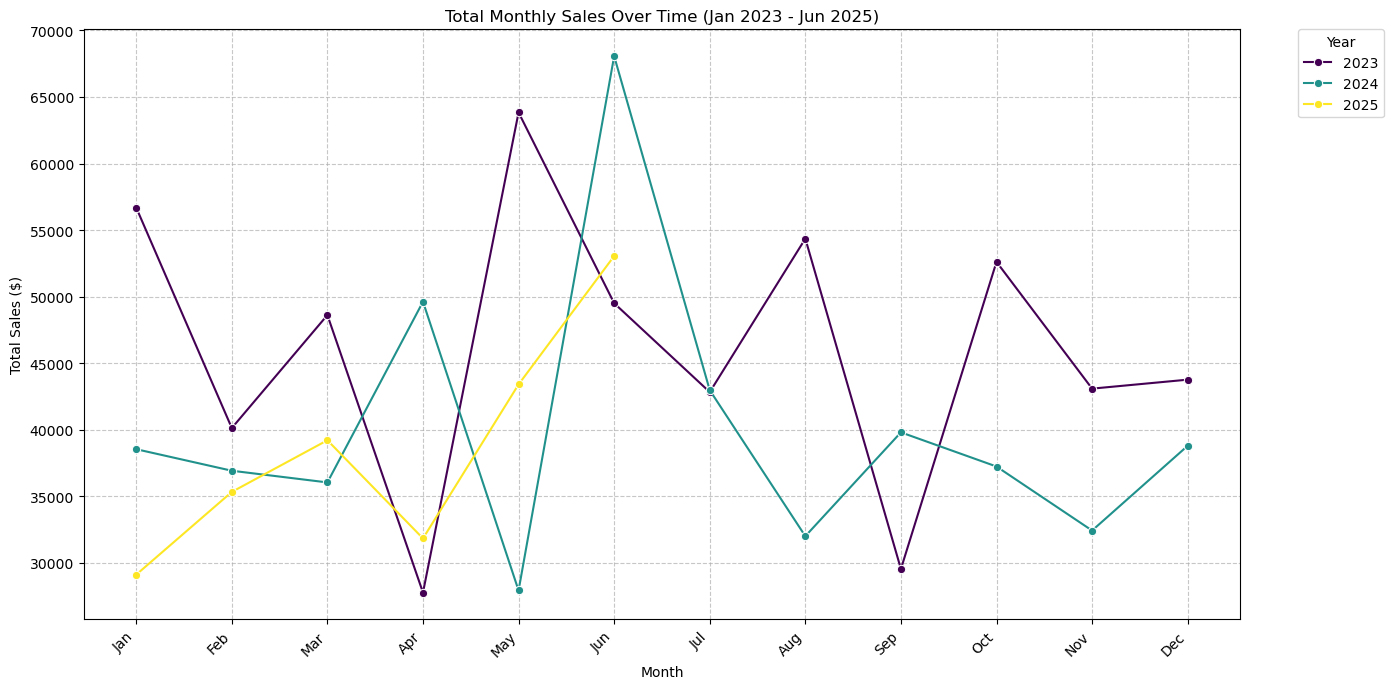

In [14]:
# Ensure 'Date' is datetime to extract year and month properly
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year, numeric Month, and Month abbreviation for plotting
df['Year'] = df['Date'].dt.year
df['Month_num'] = df['Date'].dt.month
df['Month_abbr'] = df['Date'].dt.strftime('%b')

# Aggregate TotalPrice by Year, Month_num, and Month_abbr
# We use Month_num for correct numerical ordering on the x-axis, and Month_abbr for display labels
monthly_sales_per_year = df.groupby(['Year', 'Month_num', 'Month_abbr'])['TotalPrice'].sum().reset_index()

# Ensure the data is sorted for correct line plotting
monthly_sales_per_year = monthly_sales_per_year.sort_values(by=['Year', 'Month_num'])

plt.figure(figsize=(14, 7))
# Use sns.lineplot with 'hue' for 'Year' to get separate colored lines
sns.lineplot(
    x='Month_num',
    y='TotalPrice',
    hue='Year',
    data=monthly_sales_per_year,
    marker='o', # Add markers to clearly show data points
    palette='viridis' # Use a distinct color palette
)

plt.title('Total Monthly Sales Over Time (Jan 2023 - Jun 2025)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.7)

# Set x-ticks to display month abbreviations (Jan-Dec) for clarity
# Create a full list of month abbreviations to ensure all are displayed in order
all_months_abbr = pd.to_datetime([f'2000-{i}-01' for i in range(1, 13)]).strftime('%b').tolist()
plt.xticks(ticks=range(1, 13), labels=all_months_abbr, rotation=45, ha='right')

# Position the legend at the far right of the chart area
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() # Adjust layout to prevent labels/legend from being cut off
plt.show()

### In-depth Analysis of OrderStatus: Unfulfilled Orders

In [15]:
total_records = len(df)
cancelled_returned_df = df[df['OrderStatus'].isin(['Cancelled', 'Returned'])]
cancelled_returned_count = len(cancelled_returned_df)
cancelled_returned_percentage_records = (cancelled_returned_count / total_records) * 100

total_sales_all_orders = df['TotalPrice'].sum()
total_sales_cancelled_returned = cancelled_returned_df['TotalPrice'].sum()
cancelled_returned_percentage_revenue = (total_sales_cancelled_returned / total_sales_all_orders) * 100

print(f"Total records: {total_records}")
print(f"Records with 'Cancelled' or 'Returned' status: {cancelled_returned_count} ({cancelled_returned_percentage_records:.2f}% of total records)")
print(f"Total sales from all orders: ${total_sales_all_orders:,.2f}")
print(f"Total sales from 'Cancelled' or 'Returned' orders: ${total_sales_cancelled_returned:,.2f} ({cancelled_returned_percentage_revenue:.2f}% of total sales)")

Total records: 1200
Records with 'Cancelled' or 'Returned' status: 497 (41.42% of total records)
Total sales from all orders: $1,264,761.96
Total sales from 'Cancelled' or 'Returned' orders: $519,673.91 (41.09% of total sales)


#### Observations on Unfulfilled Orders:

As observed, a substantial portion of our business, specifically **41.4% of all records** and representing **41.1% of total sales revenue ($519,674.00)**, falls under 'Cancelled' or 'Returned' statuses. This indicates a significant amount of potential revenue that is not being realized due to unfulfilled orders.

This high proportion of unfulfilled orders suggests a systemic issue rather than isolated incidents. It's crucial to investigate if specific factors contribute to these cancellations and returns.

### Analysing `OrderStatus` by Payment Method

OrderStatus,Cancelled,Cancelled Rate,Returned,Returned Rate,Total
PaymentMethod,,,,,
Cash,49,19.918699,57,23.170732,246
Credit Card,54,23.076923,49,20.940171,234
Debit Card,44,18.965517,51,21.982759,232
Gift Card,50,21.739130,52,22.608696,230
Online,53,20.542636,38,14.728682,258


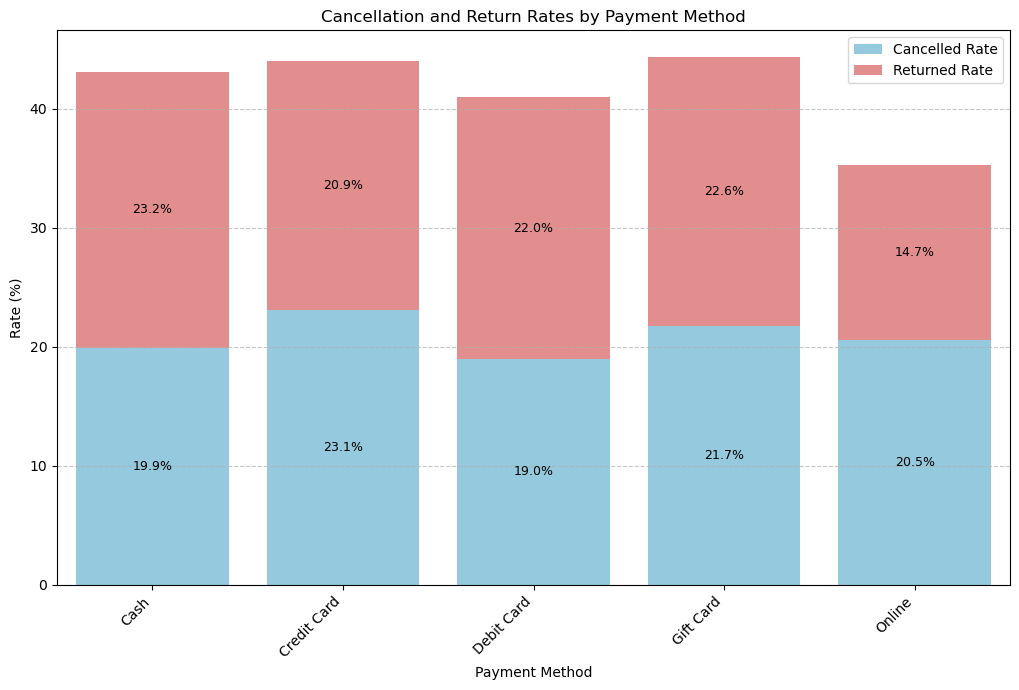

In [16]:
order_status_by_payment = df.groupby(['PaymentMethod', 'OrderStatus']).size().unstack(fill_value=0)
order_status_by_payment['Total'] = order_status_by_payment.sum(axis=1)

# Calculate percentages
for status in ['Cancelled', 'Returned']:
    order_status_by_payment[f'{status} Rate'] = (order_status_by_payment[status] / order_status_by_payment['Total']) * 100

display(order_status_by_payment[['Cancelled', 'Cancelled Rate', 'Returned', 'Returned Rate', 'Total']])

# Visualize the distribution of Cancelled/Returned rates across payment methods
plt.figure(figsize=(10.3, 7))
ax = sns.barplot(x=order_status_by_payment.index, y='Cancelled Rate', data=order_status_by_payment.reset_index(), color='skyblue', label='Cancelled Rate')
sns.barplot(x=order_status_by_payment.index, y='Returned Rate', data=order_status_by_payment.reset_index(), color='lightcoral', label='Returned Rate', bottom=order_status_by_payment['Cancelled Rate'])

# Add data labels for Cancelled Rate
for i, (method, row) in enumerate(order_status_by_payment.iterrows()):
    ax.text(i, row['Cancelled Rate'] / 2, f"{row['Cancelled Rate']:.1f}%", color='black', ha="center", va="center", fontsize=9)
    ax.text(i, row['Cancelled Rate'] + row['Returned Rate'] / 2, f"{row['Returned Rate']:.1f}%", color='black', ha="center", va="center", fontsize=9)

plt.title('Cancellation and Return Rates by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation: Order Status vs. Payment Method

Upon cross-referencing order statuses with `PaymentMethod`, there isn't a significant skew. Cancellation rates hover fairly evenly between approximately 19-25% across different payment methods. Similarly, return rates also show a consistent pattern. This suggests that the prevalence of unfulfilled orders (Cancelled or Returned) is **not predominantly tied to a specific payment method**.

This finding reinforces the idea that the high rate of unfulfilled orders is a systemic issue rather than being isolated to customer preferences for certain payment types.

### Analysing `OrderStatus` by Product

OrderStatus,Cancelled,Cancelled Rate,Returned,Returned Rate,Total
Product,,,,,
Chair,45,25.280899,28,15.730337,178
Desk,35,20.588235,32,18.823529,170
Laptop,35,20.231214,39,22.543353,173
Monitor,35,21.472393,36,22.085890,163
Phone,31,19.871795,31,19.871795,156
Printer,35,19.337017,38,20.994475,181
Tablet,34,18.994413,43,24.022346,179


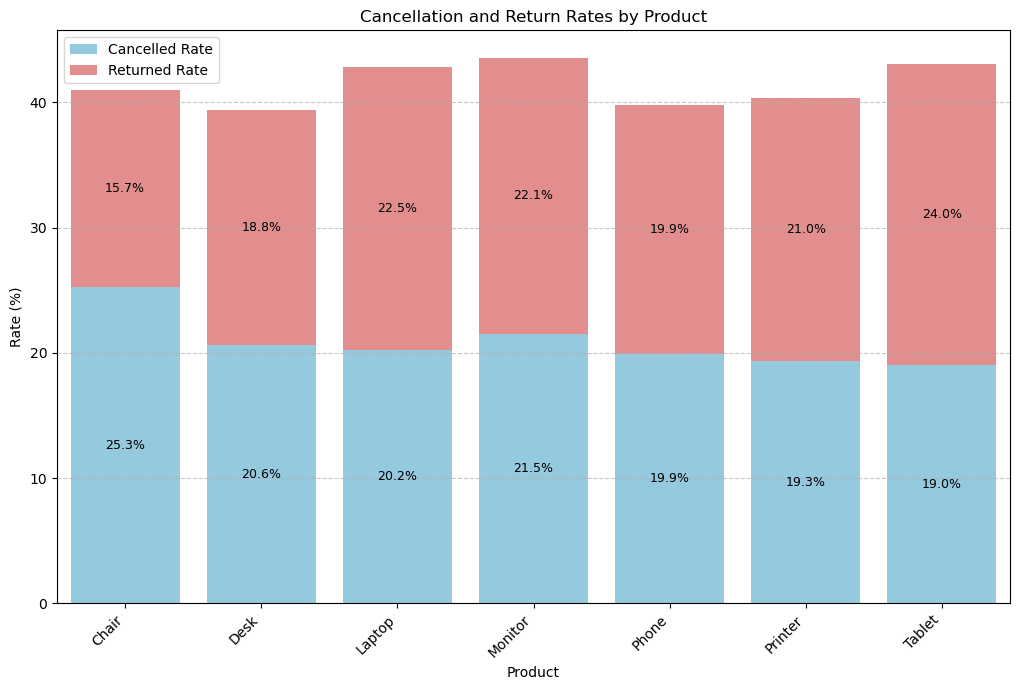

In [17]:
order_status_by_product = df.groupby(['Product', 'OrderStatus']).size().unstack(fill_value=0)
order_status_by_product['Total'] = order_status_by_product.sum(axis=1)

# Calculate percentages
for status in ['Cancelled', 'Returned']:
    order_status_by_product[f'{status} Rate'] = (order_status_by_product[status] / order_status_by_product['Total']) * 100

display(order_status_by_product[['Cancelled', 'Cancelled Rate', 'Returned', 'Returned Rate', 'Total']])

# Visualize the distribution of Cancelled/Returned rates across products
plt.figure(figsize=(10.3, 7))
ax = sns.barplot(x=order_status_by_product.index, y='Cancelled Rate', data=order_status_by_product.reset_index(), color='skyblue', label='Cancelled Rate')
sns.barplot(x=order_status_by_product.index, y='Returned Rate', data=order_status_by_product.reset_index(), color='lightcoral', label='Returned Rate', bottom=order_status_by_product['Cancelled Rate'])

# Add data labels for Cancelled Rate
for i, (product, row) in enumerate(order_status_by_product.iterrows()):
    ax.text(i, row['Cancelled Rate'] / 2, f"{row['Cancelled Rate']:.1f}%", color='black', ha="center", va="center", fontsize=9)
    ax.text(i, row['Cancelled Rate'] + row['Returned Rate'] / 2, f"{row['Returned Rate']:.1f}%", color='black', ha="center", va="center", fontsize=9)

plt.title('Cancellation and Return Rates by Product')
plt.xlabel('Product')
plt.ylabel('Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation: Order Status vs. Product

Similar to payment methods, an analysis of order status by `Product` reveals no strong skew in cancellation or return rates. The rates for 'Cancelled' and 'Returned' orders remain fairly consistent across different product categories. This further supports the conclusion that the issue of unfulfilled orders is **not tied to specific product categories**.

This finding is significant because it suggests that the problem is widespread across the product catalog rather than being concentrated on a few problematic items.

### Analysing OrderStatus by CouponUsage

OrderStatus,Cancelled,Cancelled Rate,Returned,Returned Rate,Total
CouponCode,,,,,
FREESHIP,67,21.405751,61,19.488818,313
SAVE10,58,20.279720,47,16.433566,286
WINTER15,67,22.945205,63,21.575342,292
~No Coupon~,58,18.770227,76,24.595469,309


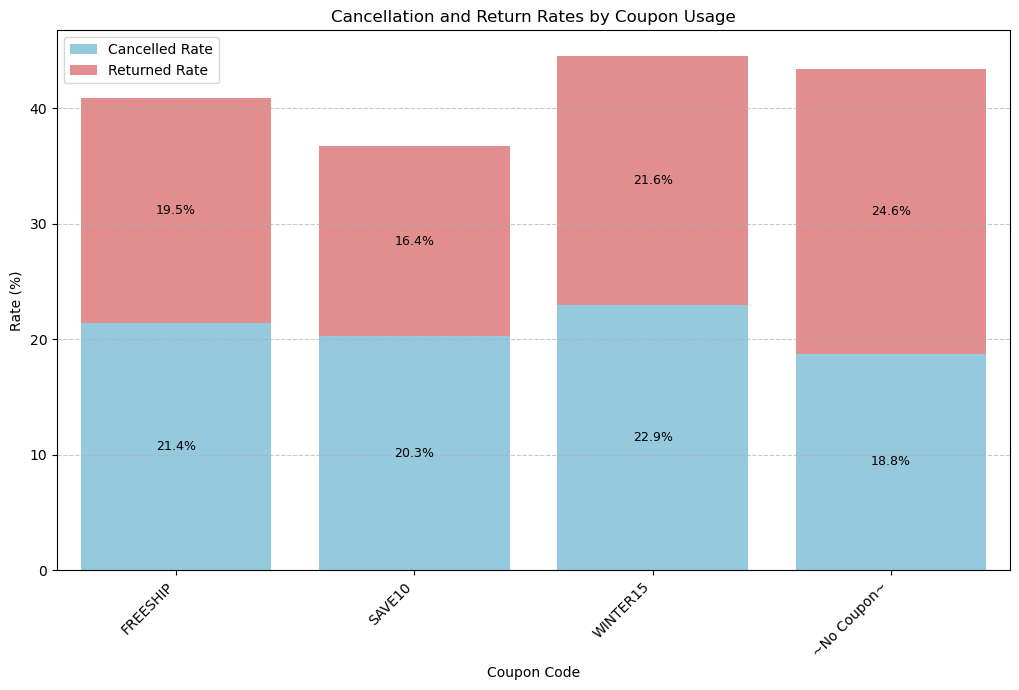

In [18]:
order_status_by_coupon = df.groupby(['CouponCode', 'OrderStatus']).size().unstack(fill_value=0)
order_status_by_coupon['Total'] = order_status_by_coupon.sum(axis=1)

# Calculate percentages
for status in ['Cancelled', 'Returned']:
    order_status_by_coupon[f'{status} Rate'] = (order_status_by_coupon[status] / order_status_by_coupon['Total']) * 100

display(order_status_by_coupon[['Cancelled', 'Cancelled Rate', 'Returned', 'Returned Rate', 'Total']])

# Visualize the distribution of Cancelled/Returned rates across coupon usage
plt.figure(figsize=(10.3, 7))
ax = sns.barplot(x=order_status_by_coupon.index, y='Cancelled Rate', data=order_status_by_coupon.reset_index(), color='skyblue', label='Cancelled Rate')
sns.barplot(x=order_status_by_coupon.index, y='Returned Rate', data=order_status_by_coupon.reset_index(), color='lightcoral', label='Returned Rate', bottom=order_status_by_coupon['Cancelled Rate'])

# Add data labels for Cancelled Rate
for i, (coupon, row) in enumerate(order_status_by_coupon.iterrows()):
    ax.text(i, row['Cancelled Rate'] / 2, f"{row['Cancelled Rate']:.1f}%", color='black', ha="center", va="center", fontsize=9)
    ax.text(i, row['Cancelled Rate'] + row['Returned Rate'] / 2, f"{row['Returned Rate']:.1f}%", color='black', ha="center", va="center", fontsize=9)

plt.title('Cancellation and Return Rates by Coupon Usage')
plt.xlabel('Coupon Code')
plt.ylabel('Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation: Order Status vs. Coupon Usage

When examining the relationship between order status and `CouponCode` usage, an interesting pattern emerges regarding returned orders:

*   **Higher Return Rate for 'No Coupon' Orders:** Orders placed without a coupon ('No Coupon') exhibit a noticeably higher return rate of **24.6%** compared to orders that used a coupon (which range from 16-22% return rate).

This observation suggests that **coupon-using customers might be more committed buyers** or perhaps more satisfied with their purchases, leading to fewer returns. This could be a valuable insight for marketing and customer retention strategies, indicating that customers incentivized by coupons may have a higher intent to keep their purchases.

While this is not a 'smoking gun' for the overall high unfulfilled order rate, it is a significant finding worth noting in the analysis.

,CouponCode,TotalPrice
0,FREESHIP,1070.405719
1,SAVE10,1065.874196
3,~No Coupon~,1043.370259
2,WINTER15,1035.902534


C:\Users\Kingsley Ezenwanne\AppData\Local\Temp\ipykernel_15844\1027913655.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CouponCode', y='TotalPrice', data=aov_by_coupon, palette='rocket')


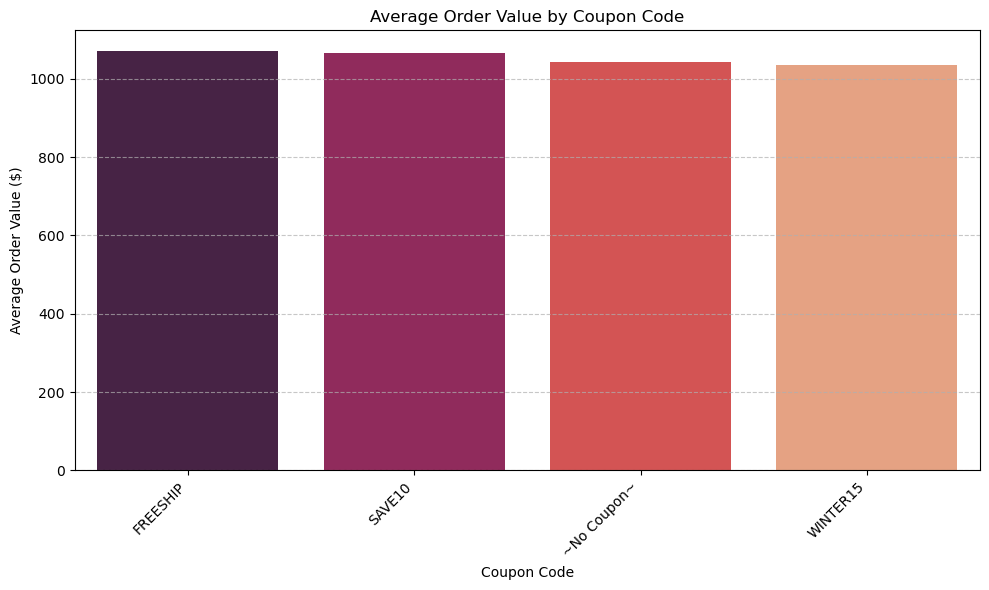

In [19]:
aov_by_coupon = df.groupby('CouponCode')['TotalPrice'].mean().reset_index()
aov_by_coupon = aov_by_coupon.sort_values(by='TotalPrice', ascending=False)

display(aov_by_coupon)

plt.figure(figsize=(10, 6))
sns.barplot(x='CouponCode', y='TotalPrice', data=aov_by_coupon, palette='rocket')
plt.title('Average Order Value by Coupon Code')
plt.xlabel('Coupon Code')
plt.ylabel('Average Order Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

,ReferralSource,TotalPrice
1,Facebook,1098.293421
3,Instagram,1062.878185
0,Email,1047.234200
2,Google,1039.176266
4,Referral,1021.691802


C:\Users\Kingsley Ezenwanne\AppData\Local\Temp\ipykernel_15844\550705195.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ReferralSource', y='TotalPrice', data=aov_by_referral, palette='mako')


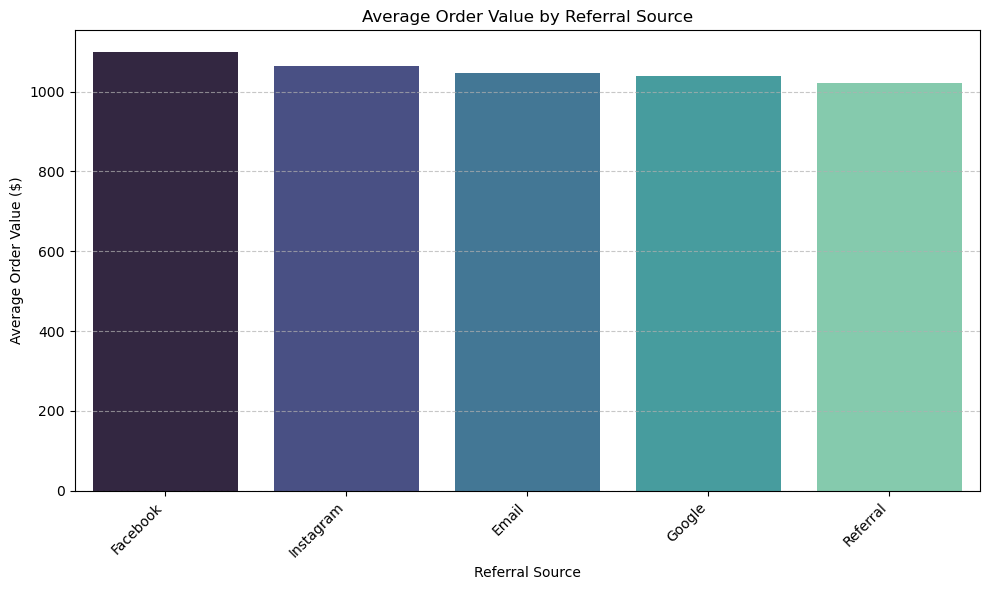

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

aov_by_referral = df.groupby('ReferralSource')['TotalPrice'].mean().reset_index()
aov_by_referral = aov_by_referral.sort_values(by='TotalPrice', ascending=False)

display(aov_by_referral)

plt.figure(figsize=(10, 6))
sns.barplot(x='ReferralSource', y='TotalPrice', data=aov_by_referral, palette='mako')
plt.title('Average Order Value by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Average Order Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

,PaymentMethod,TotalPrice
1,Credit Card,1127.553974
3,Gift Card,1070.973565
0,Cash,1056.041829
4,Online,1017.220698
2,Debit Card,1001.556810


C:\Users\Kingsley Ezenwanne\AppData\Local\Temp\ipykernel_15844\2403671929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PaymentMethod', y='TotalPrice', data=aov_by_payment, palette='crest')


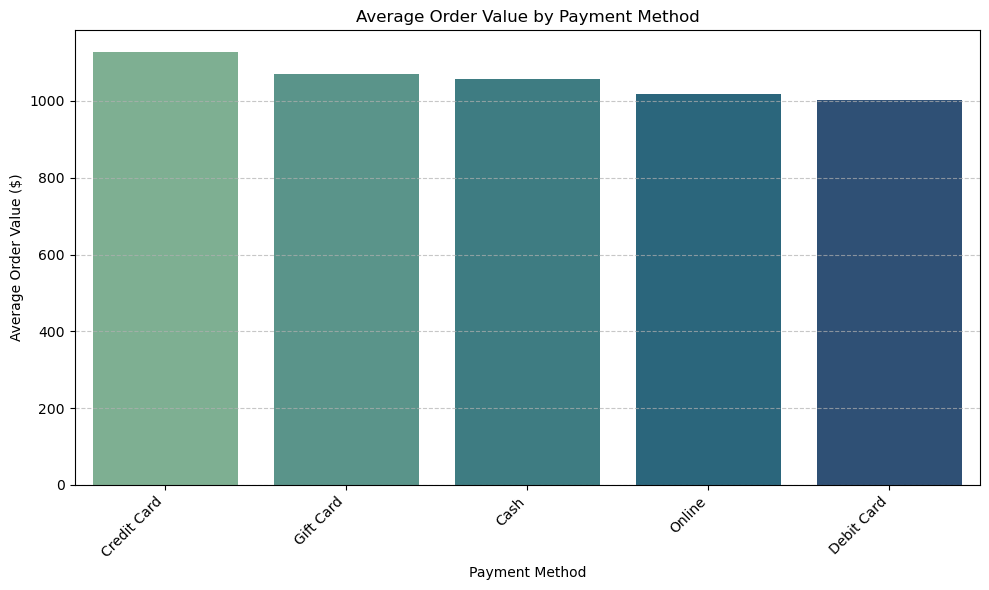

In [21]:
aov_by_payment = df.groupby('PaymentMethod')['TotalPrice'].mean().reset_index()
aov_by_payment = aov_by_payment.sort_values(by='TotalPrice', ascending=False)

display(aov_by_payment)

plt.figure(figsize=(10, 6))
sns.barplot(x='PaymentMethod', y='TotalPrice', data=aov_by_payment, palette='crest')
plt.title('Average Order Value by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Order Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Key Findings

1.  **High Rate of Unfulfilled Orders:** A critical finding is that **41.42% of all orders and 41.09% of total potential revenue are lost due to cancelled or returned orders**. This is a systemic issue, as the rates remain consistent across different payment methods and product categories.
2.  **`TotalPrice` Outliers as Signal:** High `TotalPrice` outliers are primarily driven by customers purchasing the maximum `Quantity` (5) of high-value products like Laptops, Printers, and Tablets. These represent legitimate, high-value transactions rather than errors.
3.  **Strong Correlations with `TotalPrice`:** Both `Quantity` and `UnitPrice` show strong positive correlations with `TotalPrice` (0.62 and 0.72 respectively), as expected. `Quantity` and `UnitPrice` are largely independent (correlation ~0.01).
4.  **Product Revenue Contribution:** 'Chair' and 'Printer' are the highest revenue-generating products, closely followed by 'Laptop'.
5.  **Coupon Usage Impact on Returns:** Orders placed **without a coupon ('No Coupon') exhibit a higher return rate (24.6%)** compared to orders using coupons (ranging from 16-22%). This suggests coupon users may be more committed buyers.
6.  **AOV by Referral Source:** `Facebook` referrals have the highest AOV (approx. $1,098), suggesting this channel attracts higher-value customers, while generic 'Referral' sources have slightly lower AOV.
7.  **AOV by Payment Method:** AOV does not vary significantly by payment method, indicating payment choice is not a key differentiator for order value.
8.  **Sales Trends:** Analysis of sales trends over time shows fluctuations, with some monthly and quarterly variations, but no drastic growth or decline within the observed period.

### Recommendations

1.  **Investigate and Address Unfulfilled Orders:** Prioritize a deep dive into the root causes of the 41% unfulfilled order rate. This requires further data collection (e.g., customer feedback, detailed return reasons, shipping issues, product quality complaints) and potentially A/B testing operational changes. This is the most impactful area for immediate business improvement.
2.  **Leverage Coupon Strategies:** Given the lower return rate among coupon users, consider expanding and diversifying coupon campaigns. This could foster greater customer commitment and reduce overall returns, indirectly boosting net revenue.
3.  **Optimize Marketing Spend for High-AOV Channels:** Focus marketing efforts and budget allocation towards channels like `Facebook` that consistently attract customers with higher Average Order Value. This can maximize revenue generation from marketing investments.
4.  **High-Value Customer Programs:** Develop loyalty programs or targeted marketing campaigns specifically for customers purchasing high-quantity, high-value items (e.g., bundles of Laptops/Printers/Tablets). These represent significant revenue drivers.
5.  **Continuous Monitoring:** Establish a system for continuous monitoring of order status metrics, AOV by segment, and sales trends to promptly detect shifts and address emerging issues or opportunities.